# Quark Meson model

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use(["science", "grid"])
import pandas as pd
from pathlib import Path
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import h5py
import plot

In [39]:
RESULTS_DIR = "../results/QM"

In [40]:
csv_path = Path(RESULTS_DIR) / "UV_params_1.csv"
print(csv_path.resolve())

uv_params = pd.read_csv(
    csv_path, 
    comment='#',
    skiprows=[3],
    skipinitialspace=True
)

uv_params

/home/kilian/Code/FRG/results/QM/UV_params_1.csv


,-0.1,1,0,0.23127,3.93503,2.1684e-19
0,-0.10,1,0.153061,0.240458,3.212880,2.710510e-20
1,-0.10,1,0.306122,0.267627,8.121010,0.000000e+00
2,-0.10,1,0.459184,0.021045,35.437600,0.000000e+00
3,-0.10,1,0.612245,0.323598,12.681900,-1.734720e-18
4,-0.10,1,0.765306,0.331984,12.420000,0.000000e+00
...,...,...,...,...,...,...
2494,0.75,1,6.887760,0.000752,0.007129,4.336810e-19
2495,0.75,1,7.040820,0.000756,0.007716,0.000000e+00
2496,0.75,1,7.193880,0.000752,0.008208,0.000000e+00
2497,0.75,1,7.346940,0.000754,0.008804,8.673620e-19


### Mean field $\rho_0$ as a function of input couplings

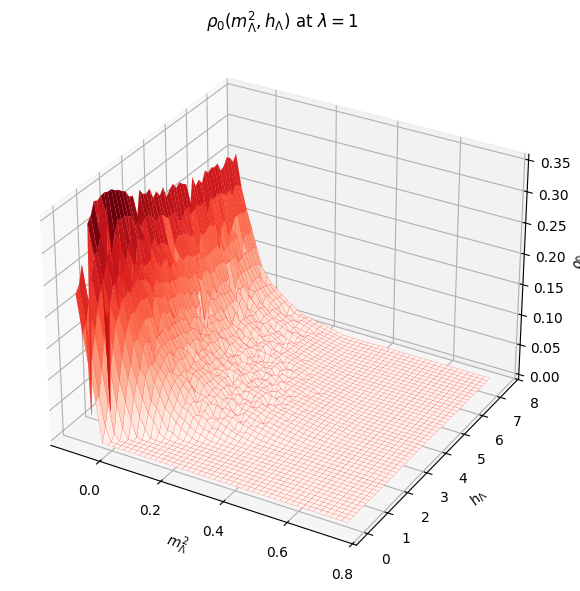

<Figure size 640x480 with 0 Axes>

In [41]:
import numpy as np
import matplotlib.pyplot as plt

col_names = ["m2", "lambda", "h", "rho0", "m2_sigma", "m2_pi", "extra"]  # "extra" = phantom col from trailing comma

uv_params = pd.read_csv(
    csv_path,
    comment="#",
    header=None,          
    names=col_names,
    skipinitialspace=True,
)

uv_params = uv_params.drop(columns=["extra"])
uv_params

# Pick a fixed lambda slice (or set this explicitly, e.g. lambda_fixed = 1.0)
lambda_fixed = uv_params["lambda"].iloc[0]
df = uv_params[np.isclose(uv_params["lambda"], lambda_fixed)]

# Pivot into a grid: rows = m2, columns = h
pivot = df.pivot(index="m2", columns="h", values="rho0")

M2, H = np.meshgrid(pivot.index.values, pivot.columns.values, indexing="ij")
RHO0 = pivot.values

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(M2, H, RHO0, cmap="Reds", edgecolor="r", linewidth=0.1)

ax.set_xlabel(r"$m^2_\Lambda$")
ax.set_ylabel(r"$h_\Lambda$")
ax.set_zlabel(r"$\rho_0$")
ax.set_title(rf"$\rho_0(m^2_\Lambda, h_\Lambda)$ at $\lambda = {lambda_fixed:.3g}$")

plt.tight_layout()
plt.show()
plt.savefig(RESULTS_DIR + "/mean_field_couplings.pdf", dpi=300, bbox_inches="tight", format="pdf")

### Meson masses

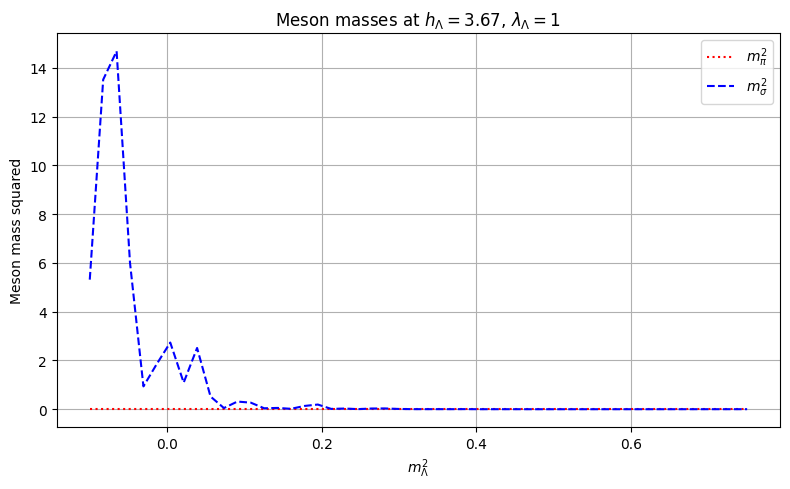

In [42]:
# Select the h_Lambda value closest to the middle of its range
h_target = 0.5 * (uv_params["h"].min() + uv_params["h"].max())
h_fixed = uv_params.loc[
    (uv_params["h"] - h_target).abs().idxmin(), "h"
]

df_masses = uv_params[
    (np.isclose(uv_params["lambda"], lambda_fixed))
    & np.isclose(uv_params["h"], h_fixed)
].sort_values("m2")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    df_masses["m2"],
    df_masses["m2_pi"],
    color="red",
    linestyle=":",
    label=r"$m_\pi^2$",
)
ax.plot(
    df_masses["m2"],
    df_masses["m2_sigma"],
    color="blue",
    linestyle="--",
    label=r"$m_\sigma^2$",
)

ax.set_xlabel(r"$m_\Lambda^2$")
ax.set_ylabel(r"Meson mass squared")
ax.set_title(rf"Meson masses at $h_\Lambda={h_fixed:.3g}$, $\lambda_\Lambda={lambda_fixed:.3g}$")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(
    Path(RESULTS_DIR) / "meson_masses_vs_m2.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()